In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf

# configuracion del tamaño de los graficos
plt.rcParams['figure.figsize'] = (8, 5)

In [45]:
# cargar el dataset
datos = pd.read_csv('Dataset/Salary_Data.csv', sep=';')
datos.columns = ['AE','Salario']
datos.head()

,AE,Salario
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


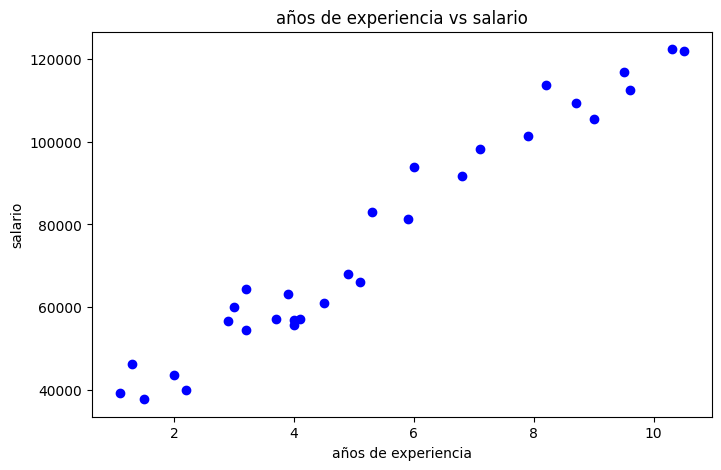

In [46]:
# grafico de dispersion
# se onserva la relacion existente entre las variables
plt.xlabel('años de experiencia')
plt.ylabel('salario')
plt.title('años de experiencia vs salario')
plt.scatter(datos['AE'], datos['Salario'], color='blue');

In [47]:
# calculamos la correlacion entre las variables
datos.corr().style.highlight_max(color='green')

,AE,Salario
AE,1.000000,0.978242
Salario,0.978242,1.000000


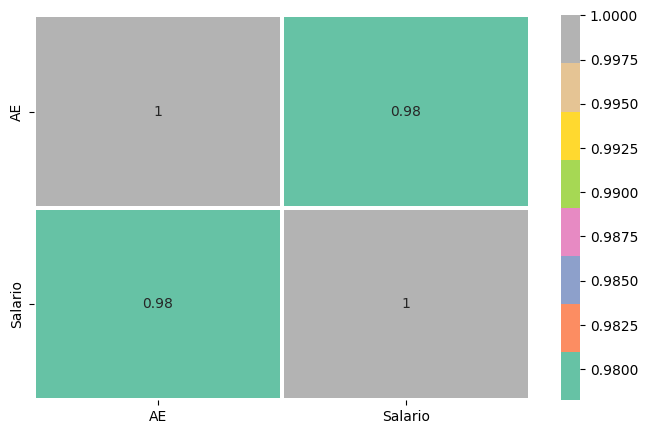

In [48]:
sns.heatmap(datos.corr(), annot=True, fmt='.2g', linewidths=1.5, cmap= 'Set2');

Ajuste polinomico - overfitting

Exactitud del modelo (R^2): 95.70%


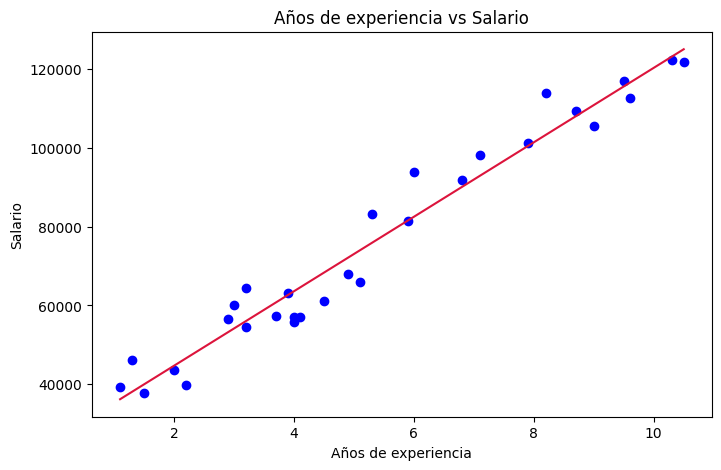

In [49]:
x=datos['AE'].values
y=datos['Salario'].values
modelo = np.poly1d(np.polyfit(x, y, 1)) # grado de ajuste polinomio
linea = np.linspace(min(x), max(x)) # escala para x
plt.scatter(x, y, color='blue')
plt.plot(linea, modelo(linea), color='crimson') # grafico de la linea de regresion
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.title('Años de experiencia vs Salario')
r2 = r2_score(y, modelo(x))
print(f'Exactitud del modelo (R^2): {r2:.2%}')

linear Regresion

In [58]:
# separamos variables independientes y dependientes
x = datos[['AE']]
y = datos['Salario']

# modelo de regresion lineal

regresion = LinearRegression()
regresion.fit(x, y)
y_pred = regresion.predict(x)

# colocamos los resultados del modelo
print(f'Intercepto: {regresion.intercept_:.4f}')
coeficiente = regresion.coef_.flatten()[0] 
print(f'Coeficiente de {x.columns[0]} = {coeficiente:.4f}')
print(f"Coeficiente de determinacion R^2: %.4f" % regresion.score(x, y))

Intercepto: 25792.2002
Coeficiente de AE = 9449.9623
Coeficiente de determinacion R^2: 0.9570


$$\Large \color {blue} Consumo = {regresion.intercept_:.4f} + {coeficiente:.4f} \cdot Peso$$

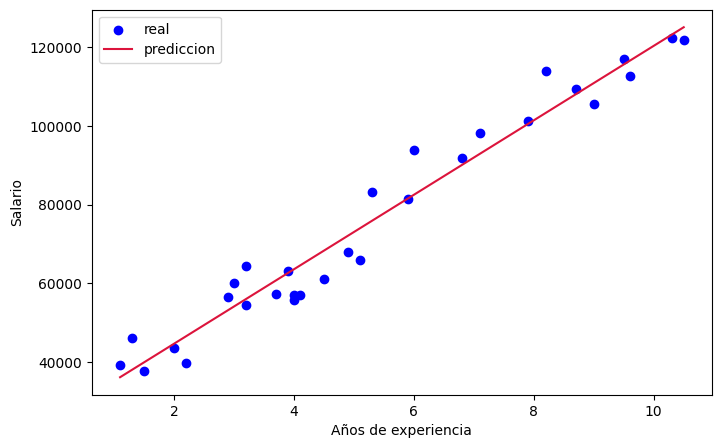

In [18]:
plt.scatter(x, y, color='blue', label = 'real')
plt.plot(x, y_pred, color='crimson', label ='prediccion')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.legend()

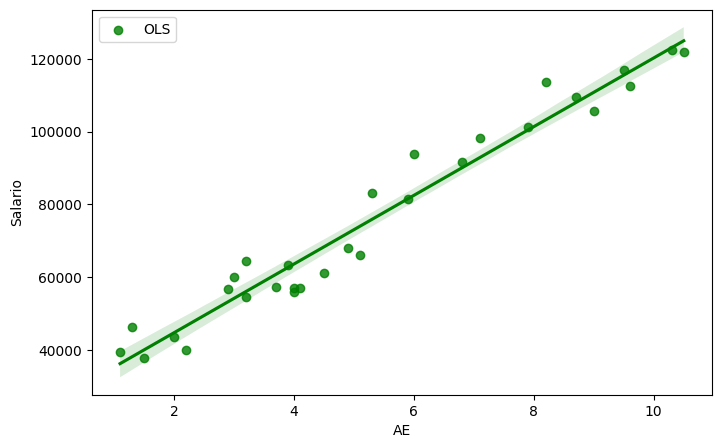

In [44]:
sns.regplot(data=datos, x='AE', y='Salario', color='green', scatter=True, label = 'OLS');
plt.legend()

Grafiquemos el error - residuo

Error cuadratico medio: 31270951.7223


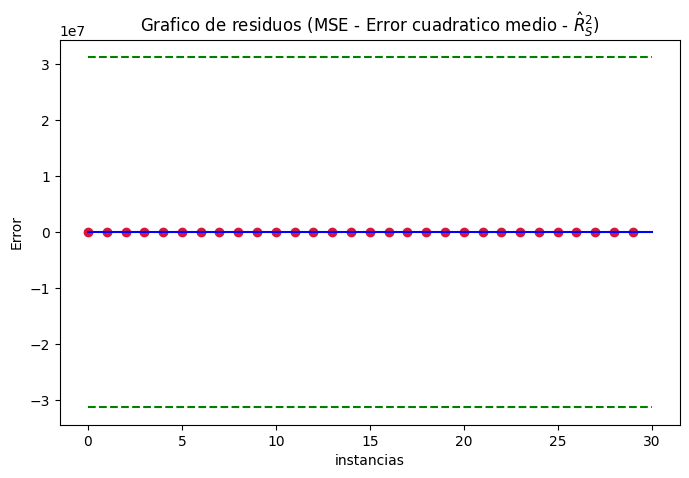

In [53]:
x1 = np.arange(len(y_pred))
plt.scatter(x1, (y - y_pred), color='crimson')
R2s = mean_squared_error(y, y_pred)
print(f'Error cuadratico medio: {R2s:.4f}')
plt.plot([0, len(y_pred)], [R2s, R2s], color='green', ls= '--')
plt.plot([0, len(y_pred)], [-R2s, -R2s], color='green', ls= '--')
plt.plot([0, len(y_pred)], [0, 0], 'b-')
plt.title('Grafico de residuos (MSE - Error cuadratico medio - $\\hat R^2_S$)')
plt.xlabel('instancias')
plt.ylabel('Error');

Separamos en datos para entrenamiento y prueba

In [57]:
x = datos[['AE']]
y = datos['Salario']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
regresion = LinearRegression()
regresion.fit(x_train, y_train)
y_pred = regresion.predict(x_test)

print(f'Intercepto: {regresion.intercept_:.4f}')
coeficiente = regresion.coef_.flatten()[0] 
print(f'Coeficiente de {x.columns[0]} = {coeficiente:.4f}')
print(f"Coeficiente de determinacion R^2: %.4f" % regresion.score(x_train, y_train))


Intercepto: 26780.0992
Coeficiente de AE = 9312.5751
Coeficiente de determinacion R^2: 0.9412


$$\Large \color{white} Salario = 26780.0992 + 9312.5751 \cdot x$$
$$\Large \color{white} R^2 = 0.9412$$

- Por cada año de experiencia(x) el sueldo sube en 9312 pesos mexicanos

In [59]:
x_test.shape

(6, 1)

OLS - minimos cuadrados ordinarios

In [55]:
datos_train =  x_train.join(y_train)
regresion1 = smf.ols(formula='Salario ~ AE', data=datos_train)
regresion1 = regresion1.fit()
regresion1.summary()
# si el p > es mayor a 0.5 esa variable no nos sirve 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Salario   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     352.1
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           5.03e-15
Time:                        09:25:09   Log-Likelihood:                -242.89
No. Observations:                  24   AIC:                             489.8
Df Residuals:                      22   BIC:                             492.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.678e+04   2818.687      9.501      0.000    2.09e+04    3.26e+04
AE          9312.5751    496.279     18.765      0.000    8283.355    1.03e+04
==============================================================================
Omnibus:                        3.105   Durbin-Watson:                   2.608
Prob(Omnibus):                  0.212   Jarque-Bera (JB):                1.567
Skew:                           0.297   Prob(JB):                        0.457
Kurtosis:                       1.898   Cond. No.                         12.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [60]:
regresion1.params

Intercept    26780.099151
AE            9312.575127
dtype: float64